In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os
# from pathlib import Path

# ZIP_PATH = "/content/drive/MyDrive/iccv_17_aesthetics_dataset/FLICKR-AES-001.zip"
# EXTRACT_DIR = "/content/drive/MyDrive/FLICKR_AES"

# Path(EXTRACT_DIR).mkdir(parents=True, exist_ok=True)

# !unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"

# print("✅ Extraction complete")
# !ls "{EXTRACT_DIR}" | head

✅ Extraction complete
40K


In [ ]:

# Optional setup
# Uncomment if needed in a fresh environment
!pip install -q git+https://github.com/openai/CLIP.git pandas numpy pillow tqdm scikit-learn matplotlib


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
import os
os.chdir("/content/drive/MyDrive/FLICKR_AES")

In [ ]:
!pwd

/content/drive/MyDrive/FLICKR_AES


In [ ]:
from pathlib import Path
import os
import random
import hashlib
import json

# Uploaded metadata defaults
SCORES_TXT_PATH = Path("ICCV 17 Aesthetics Dataset Scores.txt")
WORKERS_CSV_PATH = Path("ICCV 17 Aesthetics Dataset Workers.csv")

# TODO: point this to the directory that contains the Flickr-AES images
IMAGE_ROOT = Path("40K")

# Output / cache dirs
OUTPUT_ROOT = Path("./flickr_aes_runs")
EMBED_CACHE_DIR = OUTPUT_ROOT / "clip_cache"
SPLIT_DIR = OUTPUT_ROOT / "splits"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"

for p in [OUTPUT_ROOT, EMBED_CACHE_DIR, SPLIT_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Repro
SEED = 42

# CLIP
CLIP_MODEL_NAME = "ViT-L/14"

# Split ratios
GLOBAL_RATIOS = {"train": 0.70, "val": 0.10, "test": 0.10, "production": 0.10}
SEEN_IMAGE_RATIOS = {"train": 0.70, "val": 0.10, "test": 0.10, "production_seen": 0.10}
NEW_USER_WORKER_RATIO = 0.20  # held out entirely for production-new-user

# Training configs
GLOBAL_BATCH_SIZE = 2048
GLOBAL_EPOCHS = 20
GLOBAL_LR = 1e-3

PERSONAL_BATCH_SIZE = 512
PERSONAL_EPOCHS = 5
PERSONAL_LR = 1e-3
USER_EMB_DIM = 64

NUM_WORKERS = 0  # safest in notebooks
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("Scores file exists:", SCORES_TXT_PATH.exists())
print("Workers file exists:", WORKERS_CSV_PATH.exists())
print("IMAGE_ROOT exists:", IMAGE_ROOT.exists())


DEVICE: cuda
Scores file exists: True
Workers file exists: True
IMAGE_ROOT exists: True


In [ ]:
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import clip

ImageFile.LOAD_TRUNCATED_IMAGES = True

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def rankdata(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a)
    sorter = np.argsort(a, kind="mergesort")
    inv = np.empty_like(sorter)
    inv[sorter] = np.arange(len(a))

    a_sorted = a[sorter]
    obs = np.r_[True, a_sorted[1:] != a_sorted[:-1]]
    dense_rank = obs.cumsum() - 1

    counts = np.bincount(dense_rank)
    cumulative = np.cumsum(counts)
    starts = cumulative - counts
    avg_ranks = (starts + cumulative - 1) / 2.0 + 1.0
    return avg_ranks[dense_rank][inv]

def pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    x = x.astype(np.float64)
    y = y.astype(np.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x ** 2).sum()) * np.sqrt((y ** 2).sum())
    if denom == 0:
        return float("nan")
    return float((x * y).sum() / denom)

def spearman_corr(x: np.ndarray, y: np.ndarray) -> float:
    return pearson_corr(rankdata(x), rankdata(y))

def split_items(items, ratios, seed=42):
    items = np.array(sorted(list(items)))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(items))
    items = items[perm]

    names = list(ratios.keys())
    vals = np.array(list(ratios.values()), dtype=float)
    vals = vals / vals.sum()

    counts = np.floor(vals * len(items)).astype(int)
    counts[-1] = len(items) - counts[:-1].sum()

    splits = {}
    start = 0
    for name, count in zip(names, counts):
        splits[name] = items[start:start + count]
        start += count
    return splits

def summarize_split_counts(df, split_col, title):
    print(f"\n{title}")
    print(df[split_col].value_counts(dropna=False))


## 1. Load and inspect the Flickr-AES metadata

In [ ]:

def load_scores_txt(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 2:
                continue
            image_name, score = parts
            if not image_name.lower().endswith(".jpg"):
                continue
            try:
                score = float(score)
            except ValueError:
                continue
            rows.append((image_name, score))
    df = pd.DataFrame(rows, columns=["image_name", "global_score"])
    df = df.drop_duplicates(subset=["image_name"]).reset_index(drop=True)
    return df

scores_df = load_scores_txt(SCORES_TXT_PATH)

workers_df = pd.read_csv(WORKERS_CSV_PATH, skipinitialspace=True)
workers_df.columns = [c.strip() for c in workers_df.columns]
workers_df = workers_df.rename(columns={"imagePair": "image_name", "worker": "worker_id", "score": "worker_score"})
workers_df["worker_score_norm"] = (workers_df["worker_score"].astype(float) - 1.0) / 4.0

print("scores_df shape:", scores_df.shape)
display(scores_df.head())

print("workers_df shape:", workers_df.shape)
display(workers_df.head())

print("\nScores stats:")
display(scores_df["global_score"].describe())

print("\nWorker score stats (raw 1-5):")
display(workers_df["worker_score"].describe())

print("\nWorker score stats normalized to [0,1]:")
display(workers_df["worker_score_norm"].describe())

print("\nUnique workers:", workers_df["worker_id"].nunique())
print("Unique worker images:", workers_df["image_name"].nunique())


scores_df shape: (40499, 2)


,image_name,global_score
0,farm6_5119_5849501483_7c21d5c65d.jpg,0.485206
1,farm7_6167_6159459192_e903d5414e.jpg,0.649201
2,farm6_5022_5602049214_6176c09055.jpg,0.670467
3,farm4_3635_3687643789_5311c69897.jpg,0.844142
4,farm2_1230_1438623421_5f75ef58a7.jpg,0.600000


workers_df shape: (203104, 4)


,worker_id,image_name,worker_score,worker_score_norm
0,A14W0IW2KGR80K,farm1_176_396297967_94dae8ad97.jpg,2,0.25
1,A14W0IW2KGR80K,farm1_106_268532564_c273eb23e6.jpg,4,0.75
2,A14W0IW2KGR80K,farm8_7224_7246491674_540646a594.jpg,4,0.75
3,A14W0IW2KGR80K,farm3_2643_4041742092_25f170c501.jpg,2,0.25
4,A14W0IW2KGR80K,farm4_3080_2922825219_1ba9c41b1a.jpg,5,1.00



Scores stats:


...


Worker score stats (raw 1-5):


,worker_score
count,203104.000000
mean,3.018340
std,1.100175
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000



Worker score stats normalized to [0,1]:


,worker_score_norm
count,203104.000000
mean,0.504585
std,0.275044
min,0.000000
25%,0.250000
50%,0.500000
75%,0.750000
max,1.000000



Unique workers: 210
Unique worker images: 41541


## 2. Resolve image file paths

In [ ]:
def build_image_lookup(image_root: Path):
    assert image_root.exists(), f"IMAGE_ROOT does not exist: {image_root}"
    lookup = {}
    for p in tqdm(list(image_root.rglob("*.jpg")), desc="Indexing image files"):
        lookup[p.name] = p
    return lookup

image_lookup = build_image_lookup(IMAGE_ROOT)
print("Indexed images:", len(image_lookup))

scores_df["image_path"] = scores_df["image_name"].map(image_lookup)
workers_df["image_path"] = workers_df["image_name"].map(image_lookup)

scores_df["exists"] = scores_df["image_path"].notna()
workers_df["exists"] = workers_df["image_path"].notna()

print("\nGlobal images found:", int(scores_df["exists"].sum()), "/", len(scores_df))
print("Worker rows with images found:", int(workers_df["exists"].sum()), "/", len(workers_df))

scores_df = scores_df[scores_df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
workers_df = workers_df[workers_df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

display(scores_df.head())
display(workers_df.head())


Indexing image files:   0%|          | 0/40984 [00:00<?, ?it/s]

Indexed images: 40984

Global images found: 40499 / 40499
Worker rows with images found: 193208 / 203104

Missing worker rows: 9896

Top workers with missing images:


,image_path
27,NaN
29,NaN
55,NaN
87,NaN
101,NaN
102,NaN
126,NaN
139,NaN
164,NaN
189,NaN


,image_name,global_score,image_path
0,farm6_5119_5849501483_7c21d5c65d.jpg,0.485206,40K/farm6_5119_5849501483_7c21d5c65d.jpg
1,farm7_6167_6159459192_e903d5414e.jpg,0.649201,40K/farm7_6167_6159459192_e903d5414e.jpg
2,farm6_5022_5602049214_6176c09055.jpg,0.670467,40K/farm6_5022_5602049214_6176c09055.jpg
3,farm4_3635_3687643789_5311c69897.jpg,0.844142,40K/farm4_3635_3687643789_5311c69897.jpg
4,farm2_1230_1438623421_5f75ef58a7.jpg,0.600000,40K/farm2_1230_1438623421_5f75ef58a7.jpg


,worker_id,image_name,worker_score,worker_score_norm,image_path
0,A14W0IW2KGR80K,farm1_176_396297967_94dae8ad97.jpg,2,0.25,40K/farm1_176_396297967_94dae8ad97.jpg
1,A14W0IW2KGR80K,farm1_106_268532564_c273eb23e6.jpg,4,0.75,40K/farm1_106_268532564_c273eb23e6.jpg
2,A14W0IW2KGR80K,farm8_7224_7246491674_540646a594.jpg,4,0.75,40K/farm8_7224_7246491674_540646a594.jpg
3,A14W0IW2KGR80K,farm3_2643_4041742092_25f170c501.jpg,2,0.25,40K/farm3_2643_4041742092_25f170c501.jpg
4,A14W0IW2KGR80K,farm4_3080_2922825219_1ba9c41b1a.jpg,5,1.00,40K/farm4_3080_2922825219_1ba9c41b1a.jpg


## 3. Create the required image-level and worker-level splits

In [ ]:

# Global model splits: image-level only
global_image_splits = split_items(scores_df["image_name"].unique(), GLOBAL_RATIOS, seed=SEED)
global_split_map = {img: split for split, imgs in global_image_splits.items() for img in imgs}
scores_df["split"] = scores_df["image_name"].map(global_split_map)

summarize_split_counts(scores_df, "split", "Global model image-level splits")

# Personalized model splits:
# Step A: hold out some workers entirely as new-user production workers
all_workers = np.array(sorted(workers_df["worker_id"].unique()))
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(all_workers))
num_new_user_workers = max(1, int(round(NEW_USER_WORKER_RATIO * len(all_workers))))
new_user_workers = set(all_workers[perm[:num_new_user_workers]])
seen_workers = set(all_workers[perm[num_new_user_workers:]])

workers_df["worker_split"] = np.where(workers_df["worker_id"].isin(new_user_workers), "production_new_user", "seen_worker_pool")

print("Seen workers:", len(seen_workers))
print("New-user production workers:", len(new_user_workers))

# Step B: within seen workers, split unique images into train/val/test/production_seen
seen_df = workers_df[workers_df["worker_id"].isin(seen_workers)].copy()
seen_image_splits = split_items(seen_df["image_name"].unique(), SEEN_IMAGE_RATIOS, seed=SEED)
seen_image_split_map = {img: split for split, imgs in seen_image_splits.items() for img in imgs}

workers_df["split"] = None
mask_seen = workers_df["worker_id"].isin(seen_workers)
workers_df.loc[mask_seen, "split"] = workers_df.loc[mask_seen, "image_name"].map(seen_image_split_map)
workers_df.loc[~mask_seen, "split"] = "production_new_user"

summarize_split_counts(workers_df, "split", "Personalized model split counts (rows)")
print("\nUnique images by split:")
print(workers_df.groupby("split")["image_name"].nunique())

print("\nUnique workers by split:")
print(workers_df.groupby("split")["worker_id"].nunique())

# Persist manifests
scores_df.to_csv(SPLIT_DIR / "flickr_global_manifest.csv", index=False)
workers_df.to_csv(SPLIT_DIR / "flickr_personalized_manifest.csv", index=False)

display(scores_df.head())
display(workers_df.head())



Global model image-level splits
split
train         28349
production     4052
val            4049
test           4049
Name: count, dtype: int64
Seen workers: 168
New-user production workers: 42

Personalized model split counts (rows)
split
train                  109019
production_new_user     37614
val                     15596
production_seen         15526
test                    15453
Name: count, dtype: int64

Unique images by split:
split
production_new_user    27045
production_seen         4096
test                    4093
train                  28657
val                     4093
Name: image_name, dtype: int64

Unique workers by split:
split
production_new_user     42
production_seen        168
test                   168
train                  168
val                    168
Name: worker_id, dtype: int64


,image_name,global_score,image_path,split
0,farm6_5119_5849501483_7c21d5c65d.jpg,0.485206,40K/farm6_5119_5849501483_7c21d5c65d.jpg,train
1,farm7_6167_6159459192_e903d5414e.jpg,0.649201,40K/farm7_6167_6159459192_e903d5414e.jpg,train
2,farm6_5022_5602049214_6176c09055.jpg,0.670467,40K/farm6_5022_5602049214_6176c09055.jpg,train
3,farm4_3635_3687643789_5311c69897.jpg,0.844142,40K/farm4_3635_3687643789_5311c69897.jpg,train
4,farm2_1230_1438623421_5f75ef58a7.jpg,0.600000,40K/farm2_1230_1438623421_5f75ef58a7.jpg,train


,worker_id,image_name,worker_score,worker_score_norm,image_path,worker_split,split
0,A14W0IW2KGR80K,farm1_176_396297967_94dae8ad97.jpg,2,0.25,40K/farm1_176_396297967_94dae8ad97.jpg,seen_worker_pool,train
1,A14W0IW2KGR80K,farm1_106_268532564_c273eb23e6.jpg,4,0.75,40K/farm1_106_268532564_c273eb23e6.jpg,seen_worker_pool,train
2,A14W0IW2KGR80K,farm8_7224_7246491674_540646a594.jpg,4,0.75,40K/farm8_7224_7246491674_540646a594.jpg,seen_worker_pool,train
3,A14W0IW2KGR80K,farm3_2643_4041742092_25f170c501.jpg,2,0.25,40K/farm3_2643_4041742092_25f170c501.jpg,seen_worker_pool,train
4,A14W0IW2KGR80K,farm4_3080_2922825219_1ba9c41b1a.jpg,5,1.00,40K/farm4_3080_2922825219_1ba9c41b1a.jpg,seen_worker_pool,train


## 4. Compute and cache CLIP embeddings first

In [ ]:
clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=DEVICE)
clip_model.eval();

BATCH_EMBED_SIZE = 512  # reduce to 64 or 32 if you hit CUDA OOM

def cache_path_for_image(image_path: Path) -> Path:
    key = str(image_path.resolve()).encode("utf-8")
    name = hashlib.md5(key).hexdigest() + ".npy"
    return EMBED_CACHE_DIR / name

def _load_preprocessed_image(image_path: Path):
    try:
        image = Image.open(image_path).convert("RGB")
        return clip_preprocess(image)
    except Exception as e:
        print(f"Failed to load image: {image_path} | {e}")
        return None

@torch.no_grad()
def compute_clip_embeddings_batch(image_paths):
    tensors = []
    valid_paths = []

    for image_path in image_paths:
        x = _load_preprocessed_image(image_path)
        if x is not None:
            tensors.append(x)
            valid_paths.append(image_path)

    if len(tensors) == 0:
        return {}

    x = torch.stack(tensors, dim=0).to(DEVICE)
    feat = clip_model.encode_image(x)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    feat = feat.detach().cpu().numpy().astype(np.float32)

    return {p: feat[i] for i, p in enumerate(valid_paths)}

def build_embedding_cache(image_paths, batch_size=BATCH_EMBED_SIZE):
    image_paths = sorted({Path(p) for p in image_paths})
    missing = [p for p in image_paths if not cache_path_for_image(p).exists()]

    print("Unique images:", len(image_paths))
    print("Missing embeddings:", len(missing))

    for start in tqdm(range(0, len(missing), batch_size), desc="Caching embeddings"):
        batch_paths = missing[start:start + batch_size]
        batch_embs = compute_clip_embeddings_batch(batch_paths)

        for p, emb in batch_embs.items():
            np.save(cache_path_for_image(p), emb)

    print("Embedding cache ready at:", EMBED_CACHE_DIR)

all_image_paths = list(scores_df["image_path"]) + list(workers_df["image_path"])
build_embedding_cache(all_image_paths)


Unique images: 40959
Missing embeddings: 40959


Caching embeddings:   0%|          | 0/80 [00:00<?, ?it/s]

Embedding cache ready at: flickr_aes_runs/clip_cache


## 5. Dataset classes from cached embeddings

In [ ]:

class GlobalCachedDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()

        emb_list = []
        target_list = []
        image_name_list = []

        for _, row in self.df.iterrows():
            emb = np.load(cache_path_for_image(Path(row["image_path"]))).astype(np.float32)
            emb_list.append(emb)
            target_list.append(float(row["global_score"]))
            image_name_list.append(row["image_name"])

        self.embs = torch.tensor(np.stack(emb_list), dtype=torch.float32)
        self.targets = torch.tensor(target_list, dtype=torch.float32).unsqueeze(1)
        self.image_names = image_name_list

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "emb": self.embs[idx],
            "target": self.targets[idx],
            "image_name": self.image_names[idx],
        }

class PersonalizedCachedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, user2idx: dict):
        self.df = df.reset_index(drop=True).copy()
        self.user2idx = user2idx

        emb_list = []
        target_list = []
        user_idx_list = []
        image_name_list = []
        worker_id_list = []

        for _, row in self.df.iterrows():
            emb = np.load(cache_path_for_image(Path(row["image_path"]))).astype(np.float32)
            emb_list.append(emb)
            target_list.append(float(row["worker_score_norm"]))
            user_idx_list.append(self.user2idx[row["worker_id"]])
            image_name_list.append(row["image_name"])
            worker_id_list.append(row["worker_id"])

        self.embs = torch.tensor(np.stack(emb_list), dtype=torch.float32)
        self.targets = torch.tensor(target_list, dtype=torch.float32).unsqueeze(1)
        self.user_idxs = torch.tensor(user_idx_list, dtype=torch.long)
        self.image_names = image_name_list
        self.worker_ids = worker_id_list

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "emb": self.embs[idx],
            "user_idx": self.user_idxs[idx],
            "target": self.targets[idx],
            "image_name": self.image_names[idx],
            "worker_id": self.worker_ids[idx],
        }

def collate_global(batch):
    return {
        "emb": torch.stack([b["emb"] for b in batch], dim=0),
        "target": torch.stack([b["target"] for b in batch], dim=0),
        "image_name": [b["image_name"] for b in batch],
    }

def collate_personal(batch):
    return {
        "emb": torch.stack([b["emb"] for b in batch], dim=0),
        "user_idx": torch.stack([b["user_idx"] for b in batch], dim=0),
        "target": torch.stack([b["target"] for b in batch], dim=0),
        "image_name": [b["image_name"] for b in batch],
        "worker_id": [b["worker_id"] for b in batch],
    }


## 6. Models

In [ ]:

class GlobalMLP(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))

class PersonalizedMLP(nn.Module):
    def __init__(self, num_users, input_dim=768, user_dim=64):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, user_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + user_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x, user_idx):
        u = self.user_embedding(user_idx)
        z = torch.cat([x, u], dim=-1)
        return torch.sigmoid(self.net(z))


## 7. Training and evaluation helpers

In [ ]:

def train_one_epoch_global(model, loader, optimizer, device):
    model.train()
    losses = []
    for batch in tqdm(loader, desc="Train Global", leave=False):
        x = batch["emb"].to(device).float()
        y = batch["target"].to(device).float()

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = F.mse_loss(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def train_one_epoch_personal(model, loader, optimizer, device):
    model.train()
    losses = []
    for batch in tqdm(loader, desc="Train Personal", leave=False):
        x = batch["emb"].to(device).float()
        u = batch["user_idx"].to(device)
        y = batch["target"].to(device).float()

        optimizer.zero_grad(set_to_none=True)
        pred = model(x, u)
        loss = F.mse_loss(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_global(model, loader, device):
    model.eval()
    preds, targets, names = [], [], []
    mse_vals, mae_vals = [], []
    for batch in tqdm(loader, desc="Eval Global", leave=False):
        x = batch["emb"].to(device).float()
        y = batch["target"].to(device).float()

        pred = model(x)
        mse_vals.append(F.mse_loss(pred, y).item())
        mae_vals.append(F.l1_loss(pred, y).item())

        preds.append(pred.squeeze(1).cpu().numpy())
        targets.append(y.squeeze(1).cpu().numpy())
        names.extend(batch["image_name"])

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    metrics = {
        "mse": float(np.mean(mse_vals)),
        "mae": float(np.mean(mae_vals)),
        "plcc": float(pearson_corr(preds, targets)),
        "srcc": float(spearman_corr(preds, targets)),
    }
    pred_df = pd.DataFrame({"image_name": names, "target": targets, "pred": preds})
    return metrics, pred_df

@torch.no_grad()
def evaluate_personal(model, loader, device):
    model.eval()
    preds, targets, names, workers = [], [], [], []
    mse_vals, mae_vals = [], []
    for batch in tqdm(loader, desc="Eval Personal", leave=False):
        x = batch["emb"].to(device).float()
        u = batch["user_idx"].to(device)
        y = batch["target"].to(device).float()

        pred = model(x, u)
        mse_vals.append(F.mse_loss(pred, y).item())
        mae_vals.append(F.l1_loss(pred, y).item())

        preds.append(pred.squeeze(1).cpu().numpy())
        targets.append(y.squeeze(1).cpu().numpy())
        names.extend(batch["image_name"])
        workers.extend(batch["worker_id"])

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    metrics = {
        "mse": float(np.mean(mse_vals)),
        "mae": float(np.mean(mae_vals)),
        "plcc": float(pearson_corr(preds, targets)),
        "srcc": float(spearman_corr(preds, targets)),
    }
    pred_df = pd.DataFrame({"image_name": names, "worker_id": workers, "target": targets, "pred": preds})
    return metrics, pred_df


## 8. Prepare dataloaders for the global model

In [ ]:

global_train_df = scores_df[scores_df["split"] == "train"].copy()
global_val_df = scores_df[scores_df["split"] == "val"].copy()
global_test_df = scores_df[scores_df["split"] == "test"].copy()
global_prod_df = scores_df[scores_df["split"] == "production"].copy()

global_train_ds = GlobalCachedDataset(global_train_df)
global_val_ds = GlobalCachedDataset(global_val_df)
global_test_ds = GlobalCachedDataset(global_test_df)
global_prod_ds = GlobalCachedDataset(global_prod_df)

global_train_loader = DataLoader(global_train_ds, batch_size=GLOBAL_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_global)
global_val_loader = DataLoader(global_val_ds, batch_size=GLOBAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_global)
global_test_loader = DataLoader(global_test_ds, batch_size=GLOBAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_global)
global_prod_loader = DataLoader(global_prod_ds, batch_size=GLOBAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_global)

print("Global splits:")
print(len(global_train_ds), len(global_val_ds), len(global_test_ds), len(global_prod_ds))


Global splits:
28349 4049 4049 4052


## 9. Train the global FLICKR-AES model

In [ ]:

global_model = GlobalMLP().to(DEVICE)
global_optimizer = torch.optim.Adam(global_model.parameters(), lr=GLOBAL_LR)

global_history = []
best_val_srcc = -1.0
best_global_ckpt = CHECKPOINT_DIR / "flickr_global_best.pth"
last_global_ckpt = CHECKPOINT_DIR / "flickr_global_last.pth"

for epoch in range(1, GLOBAL_EPOCHS + 1):
    train_mse = train_one_epoch_global(global_model, global_train_loader, global_optimizer, DEVICE)
    val_metrics, _ = evaluate_global(global_model, global_val_loader, DEVICE)

    row = {
        "epoch": epoch,
        "train_mse": train_mse,
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_plcc": val_metrics["plcc"],
        "val_srcc": val_metrics["srcc"],
    }
    global_history.append(row)
    print(row)

    torch.save({
        "epoch": epoch,
        "model_state_dict": global_model.state_dict(),
        "optimizer_state_dict": global_optimizer.state_dict(),
        "history": global_history,
        "val_metrics": val_metrics,
    }, last_global_ckpt)

    if val_metrics["srcc"] > best_val_srcc:
        best_val_srcc = val_metrics["srcc"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": global_model.state_dict(),
            "optimizer_state_dict": global_optimizer.state_dict(),
            "history": global_history,
            "val_metrics": val_metrics,
        }, best_global_ckpt)
        print("Saved best global checkpoint:", best_global_ckpt)

global_history_df = pd.DataFrame(global_history)
display(global_history_df.tail())


Train Global:   0%|          | 0/14 [00:00<?, ?it/s]

Eval Global:   0%|          | 0/2 [00:00<?, ?it/s]

{'epoch': 1, 'train_mse': 0.025290564367813722, 'val_mse': 0.02118770033121109, 'val_mae': 0.11699134111404419, 'val_plcc': 0.6569529311019515, 'val_srcc': 0.6370178084619796}
Saved best global checkpoint: flickr_aes_runs/checkpoints/flickr_global_best.pth


Train Global:   0%|          | 0/14 [00:00<?, ?it/s]

Eval Global:   0%|          | 0/2 [00:00<?, ?it/s]

...

{'epoch': 29, 'train_mse': 0.0034311392477580477, 'val_mse': 0.009159896988421679, 'val_mae': 0.0751761682331562, 'val_plcc': 0.7928491211803536, 'val_srcc': 0.7640979107259136}


Train Global:   0%|          | 0/14 [00:00<?, ?it/s]

Eval Global:   0%|          | 0/2 [00:00<?, ?it/s]

{'epoch': 30, 'train_mse': 0.003146240720525384, 'val_mse': 0.009241882245987654, 'val_mae': 0.07551107183098793, 'val_plcc': 0.7917695507942305, 'val_srcc': 0.7641720977216405}


,epoch,train_mse,val_mse,val_mae,val_plcc,val_srcc
25,26,0.003947,0.008944,0.074371,0.798309,0.771568
26,27,0.003724,0.009044,0.074774,0.795257,0.768384
27,28,0.003577,0.009226,0.075655,0.797561,0.771678
28,29,0.003431,0.009160,0.075176,0.792849,0.764098
29,30,0.003146,0.009242,0.075511,0.791770,0.764172


Eval Global:   0%|          | 0/2 [00:00<?, ?it/s]

Eval Global:   0%|          | 0/2 [00:00<?, ?it/s]

Global VAL: {'mse': 0.008147676941007376, 'mae': 0.07116115093231201, 'plcc': 0.8144202827954353, 'srcc': 0.7909813932428376}
Global TEST: {'mse': 0.008754922542721033, 'mae': 0.07290163263678551, 'plcc': 0.7929068557772334, 'srcc': 0.7729673961817944}


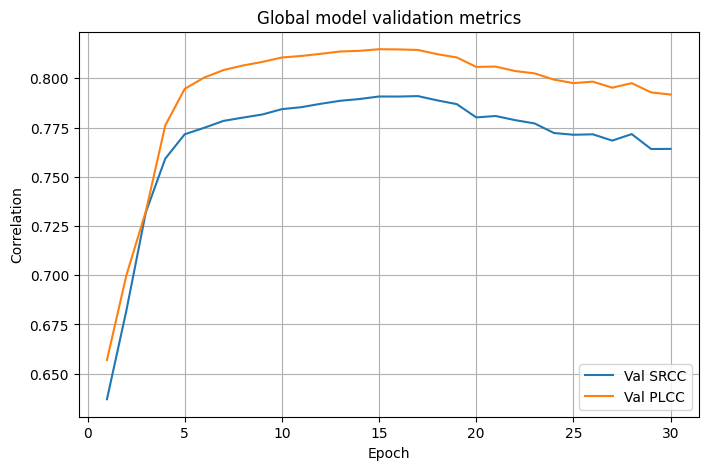

In [ ]:

best_bundle = torch.load(best_global_ckpt, map_location=DEVICE)
global_model.load_state_dict(best_bundle["model_state_dict"])

global_val_metrics, global_val_pred = evaluate_global(global_model, global_val_loader, DEVICE)
global_test_metrics, global_test_pred = evaluate_global(global_model, global_test_loader, DEVICE)
#global_prod_metrics, global_prod_pred = evaluate_global(global_model, global_prod_loader, DEVICE)

print("Global VAL:", global_val_metrics)
print("Global TEST:", global_test_metrics)
#print("Global PRODUCTION:", global_prod_metrics)

global_val_pred.to_csv(OUTPUT_ROOT / "global_val_predictions.csv", index=False)
global_test_pred.to_csv(OUTPUT_ROOT / "global_test_predictions.csv", index=False)
#global_prod_pred.to_csv(OUTPUT_ROOT / "global_production_predictions.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(global_history_df["epoch"], global_history_df["val_srcc"], label="Val SRCC")
plt.plot(global_history_df["epoch"], global_history_df["val_plcc"], label="Val PLCC")
plt.xlabel("Epoch")
plt.ylabel("Correlation")
plt.title("Global model validation metrics")
plt.legend()
plt.grid(True)
plt.show()


## 10. Prepare dataloaders for the personalized model

In [ ]:

personal_train_df = workers_df[workers_df["split"] == "train"].copy()
personal_val_df = workers_df[workers_df["split"] == "val"].copy()
personal_test_df = workers_df[workers_df["split"] == "test"].copy()
personal_prod_seen_df = workers_df[workers_df["split"] == "production_seen"].copy()
personal_prod_new_user_df = workers_df[workers_df["split"] == "production_new_user"].copy()

all_seen_workers = sorted(workers_df.loc[workers_df["worker_split"] == "seen_worker_pool", "worker_id"].unique())
user2idx = {u: i for i, u in enumerate(all_seen_workers)}
seen_worker_set = set(user2idx.keys())

# Keep seen-worker splits only for personalized model training/evaluation
personal_train_ds = PersonalizedCachedDataset(personal_train_df, user2idx)
personal_val_ds = PersonalizedCachedDataset(personal_val_df[personal_val_df["worker_id"].isin(seen_worker_set)].copy(), user2idx)
personal_test_ds = PersonalizedCachedDataset(personal_test_df[personal_test_df["worker_id"].isin(seen_worker_set)].copy(), user2idx)
personal_prod_seen_ds = PersonalizedCachedDataset(personal_prod_seen_df[personal_prod_seen_df["worker_id"].isin(seen_worker_set)].copy(), user2idx)

personal_train_loader = DataLoader(personal_train_ds, batch_size=PERSONAL_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_personal)
personal_val_loader = DataLoader(personal_val_ds, batch_size=PERSONAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_personal)
personal_test_loader = DataLoader(personal_test_ds, batch_size=PERSONAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_personal)
personal_prod_seen_loader = DataLoader(personal_prod_seen_ds, batch_size=PERSONAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False, collate_fn=collate_personal)

print("Personalized seen-worker splits:")
print(len(personal_train_ds), len(personal_val_ds), len(personal_test_ds), len(personal_prod_seen_ds))
print("Held-out new-user production rows:", len(personal_prod_new_user_df))
print("Num seen workers / user embeddings:", len(user2idx))


Personalized seen-worker splits:
109019 15596 15453 15526
Held-out new-user production rows: 37614
Num seen workers / user embeddings: 168


## 11. Train the personalized FLICKR-AES model

In [ ]:

personal_model = PersonalizedMLP(num_users=len(user2idx), user_dim=USER_EMB_DIM).to(DEVICE)
personal_optimizer = torch.optim.Adam(personal_model.parameters(), lr=PERSONAL_LR)

personal_history = []
best_val_srcc = -1.0
best_personal_ckpt = CHECKPOINT_DIR / "flickr_personalized_best.pth"
last_personal_ckpt = CHECKPOINT_DIR / "flickr_personalized_last.pth"

for epoch in range(1, PERSONAL_EPOCHS + 1):
    train_mse = train_one_epoch_personal(personal_model, personal_train_loader, personal_optimizer, DEVICE)
    val_metrics, _ = evaluate_personal(personal_model, personal_val_loader, DEVICE)

    row = {
        "epoch": epoch,
        "train_mse": train_mse,
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_plcc": val_metrics["plcc"],
        "val_srcc": val_metrics["srcc"],
    }
    personal_history.append(row)
    print(row)

    torch.save({
        "epoch": epoch,
        "model_state_dict": personal_model.state_dict(),
        "optimizer_state_dict": personal_optimizer.state_dict(),
        "history": personal_history,
        "val_metrics": val_metrics,
        "user2idx": user2idx,
    }, last_personal_ckpt)

    if val_metrics["srcc"] > best_val_srcc:
        best_val_srcc = val_metrics["srcc"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": personal_model.state_dict(),
            "optimizer_state_dict": personal_optimizer.state_dict(),
            "history": personal_history,
            "val_metrics": val_metrics,
            "user2idx": user2idx,
        }, best_personal_ckpt)
        print("Saved best personalized checkpoint:", best_personal_ckpt)

personal_history_df = pd.DataFrame(personal_history)
display(personal_history_df.tail())


Train Personal:   0%|          | 0/213 [00:00<?, ?it/s]

Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

{'epoch': 1, 'train_mse': 0.04370765987906098, 'val_mse': 0.03733677176698562, 'val_mae': 0.14916763238368497, 'val_plcc': 0.7081131581483734, 'val_srcc': 0.7050827107424986}
Saved best personalized checkpoint: flickr_aes_runs/checkpoints/flickr_personalized_best.pth


Train Personal:   0%|          | 0/213 [00:00<?, ?it/s]

Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

...

{'epoch': 29, 'train_mse': 0.011735070536149219, 'val_mse': 0.03846252983015391, 'val_mae': 0.14496830274020472, 'val_plcc': 0.7102324816338502, 'val_srcc': 0.7038459930224664}


Train Personal:   0%|          | 0/213 [00:00<?, ?it/s]

Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

{'epoch': 30, 'train_mse': 0.011334977890998825, 'val_mse': 0.03861993425075085, 'val_mae': 0.14523040863775438, 'val_plcc': 0.7106578046045879, 'val_srcc': 0.7051723493844413}


,epoch,train_mse,val_mse,val_mae,val_plcc,val_srcc
25,26,0.012705,0.038114,0.144109,0.713802,0.708257
26,27,0.012339,0.038554,0.144949,0.711267,0.705283
27,28,0.011973,0.038419,0.144517,0.711472,0.705765
28,29,0.011735,0.038463,0.144968,0.710232,0.703846
29,30,0.011335,0.038620,0.145230,0.710658,0.705172


Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

Eval Personal:   0%|          | 0/31 [00:00<?, ?it/s]

Personalized VAL: {'mse': 0.0339072737241945, 'mae': 0.1412674854359319, 'plcc': 0.7409887524906192, 'srcc': 0.7356148701928884}
Personalized TEST: {'mse': 0.03470332358753489, 'mae': 0.1434901996004966, 'plcc': 0.7374659160594318, 'srcc': 0.7293981295639461}
Personalized PRODUCTION_SEEN: {'mse': 0.03537846116289016, 'mae': 0.14459909883237654, 'plcc': 0.733750134199899, 'srcc': 0.7266118510975899}


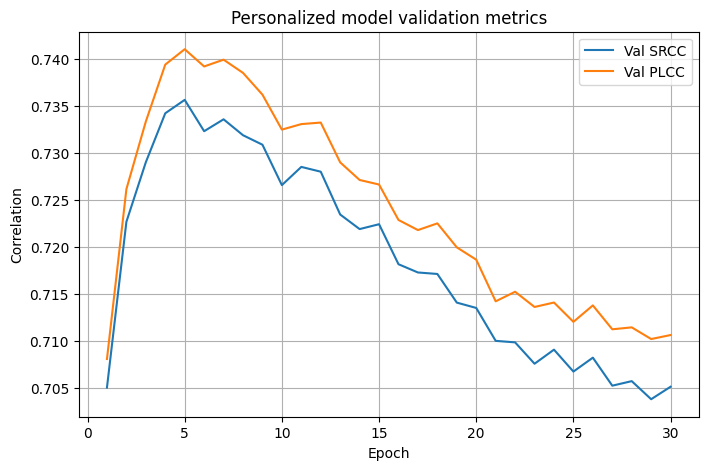

In [ ]:

best_bundle = torch.load(best_personal_ckpt, map_location=DEVICE)
personal_model.load_state_dict(best_bundle["model_state_dict"])

personal_val_metrics, personal_val_pred = evaluate_personal(personal_model, personal_val_loader, DEVICE)
personal_test_metrics, personal_test_pred = evaluate_personal(personal_model, personal_test_loader, DEVICE)
#personal_prod_seen_metrics, personal_prod_seen_pred = evaluate_personal(personal_model, personal_prod_seen_loader, DEVICE)

print("Personalized VAL:", personal_val_metrics)
print("Personalized TEST:", personal_test_metrics)
#print("Personalized PRODUCTION_SEEN:", personal_prod_seen_metrics)

personal_val_pred.to_csv(OUTPUT_ROOT / "personal_val_predictions.csv", index=False)
personal_test_pred.to_csv(OUTPUT_ROOT / "personal_test_predictions.csv", index=False)
#personal_prod_seen_pred.to_csv(OUTPUT_ROOT / "personal_production_seen_predictions.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(personal_history_df["epoch"], personal_history_df["val_srcc"], label="Val SRCC")
plt.plot(personal_history_df["epoch"], personal_history_df["val_plcc"], label="Val PLCC")
plt.xlabel("Epoch")
plt.ylabel("Correlation")
plt.title("Personalized model validation metrics")
plt.legend()
plt.grid(True)
plt.show()
